### 8.1 Fungsi Evaluasi dan Utility Plot

In [ ]:
# === SEL INISIALISASI ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

os.makedirs('results/plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

X_train_scaled = pd.read_csv('data/processed/X_train.csv')
X_test_scaled  = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('data/processed/y_test.csv').squeeze()
df_train = pd.read_csv('data/processed/df_train_datetime.csv', parse_dates=['datetime'])
df_test  = pd.read_csv('data/processed/df_test_datetime.csv',  parse_dates=['datetime'])

print(f"X_train: {X_train_scaled.shape}, X_test: {X_test_scaled.shape}")

X_train: (837697, 98), X_test: (209438, 98)


In [ ]:
def evaluate(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

def plot_predictions(dates, y_true, y_pred, model_name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    dates  = np.array(dates)
    n = min(500, len(y_true))
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))
    axes[0].plot(dates[:n], y_true[:n], label='Aktual', alpha=0.7)
    axes[0].plot(dates[:n], y_pred[:n], label='Prediksi', alpha=0.7)
    axes[0].set_title(f'{model_name} - Prediksi vs Aktual')
    axes[0].legend()
    axes[1].scatter(y_true, y_pred, alpha=0.3, s=5)
    axes[1].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    axes[1].set_xlabel('Aktual')
    axes[1].set_ylabel('Prediksi')
    axes[1].set_title(f'{model_name} - Scatter Aktual vs Prediksi')
    plt.tight_layout()
    fname = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'results/plots/{fname}_prediction.png', dpi=120)
    plt.show()
    print(f'Plot disimpan ke results/plots/{fname}_prediction.png')

### 8.2 Baseline Model

Sebagai referensi bawah, kita gunakan dua prediksi sederhana:
- **Naive**: prediksi = nilai AQI jam sebelumnya
- **Rolling Mean**: rata-rata 7 hari terakhir dari data training

In [ ]:
# Baseline Naive
# Karena data time series gabungan dari banyak kota, naive prediction untuk setiap baris
# adalah nilai AQI jam sebelumnya dari kota yang sama, yang sudah disimpan di kolom 'aqi_lag1'
naive_pred = X_test_scaled['aqi_lag1'].values
y_naive_true = y_test.values

# Jika ada NaN pada aqi_lag1 (misal di awal/karena missing value), kita filter agar evaluasinya adil dan valid
valid_mask = ~np.isnan(naive_pred)
naive_pred = naive_pred[valid_mask]
y_naive_true = y_naive_true[valid_mask]

# Baseline Rolling Mean (24 jam terakhir dari kota yang sama, disimpan di kolom 'aqi_roll24m')
rolling_pred = X_test_scaled['aqi_roll24m'].values
y_rolling_true = y_test.values

# Filter NaN secara aman agar evaluasi valid
valid_mask_roll = ~np.isnan(rolling_pred)
rolling_pred = rolling_pred[valid_mask_roll]
y_rolling_true = y_rolling_true[valid_mask_roll]

metrics_list = []
metrics_list.append(evaluate(y_naive_true, naive_pred, 'Baseline Naive'))
metrics_list.append(evaluate(y_rolling_true, rolling_pred, 'Baseline Rolling Mean (24h)'))

pd.DataFrame(metrics_list)

,Model,MAE,RMSE,R2,MAPE
0,Baseline Naive,1.251841,2.789903,0.996482,1.369496
1,Baseline Rolling Mean (24h),8.593087,12.403936,0.930463,10.044196


### 8.3 XGBoost Regressor

**Alasan pemilihan XGBoost sebagai model utama:**
- Dataset sudah dalam bentuk tabular dengan 104 fitur yang di-rekayasa secara eksplisit (lag, rolling, cyclical, interaksi polutan) — ini adalah domain di mana gradient boosting secara konsisten unggul atas LSTM (Grinsztajn et al., NeurIPS 2022)
- Ketergantungan temporal sudah direpresentasikan secara eksplisit sebagai fitur (`aqi_lag1`, `aqi_roll24m`, dll.), sehingga LSTM tidak memiliki "rahasia" tambahan untuk dipelajari dari raw sequence
- Skala data 837K baris: XGBoost selesai dalam menit, LSTM membutuhkan berjam-jam dan rentan `MemoryError`
- Built-in early stopping mencegah overfitting secara otomatis
- Feature importance langsung tersedia untuk interpretasi hasil

Train: (753928, 98), Val: (83769, 98), Test: (209438, 98)
[0]	validation_0-rmse:43.98673
[50]	validation_0-rmse:4.34430
[100]	validation_0-rmse:1.89460
[150]	validation_0-rmse:1.75623
[200]	validation_0-rmse:1.71081
[230]	validation_0-rmse:1.76467

Best iteration : 210
Best val RMSE  : 1.7010


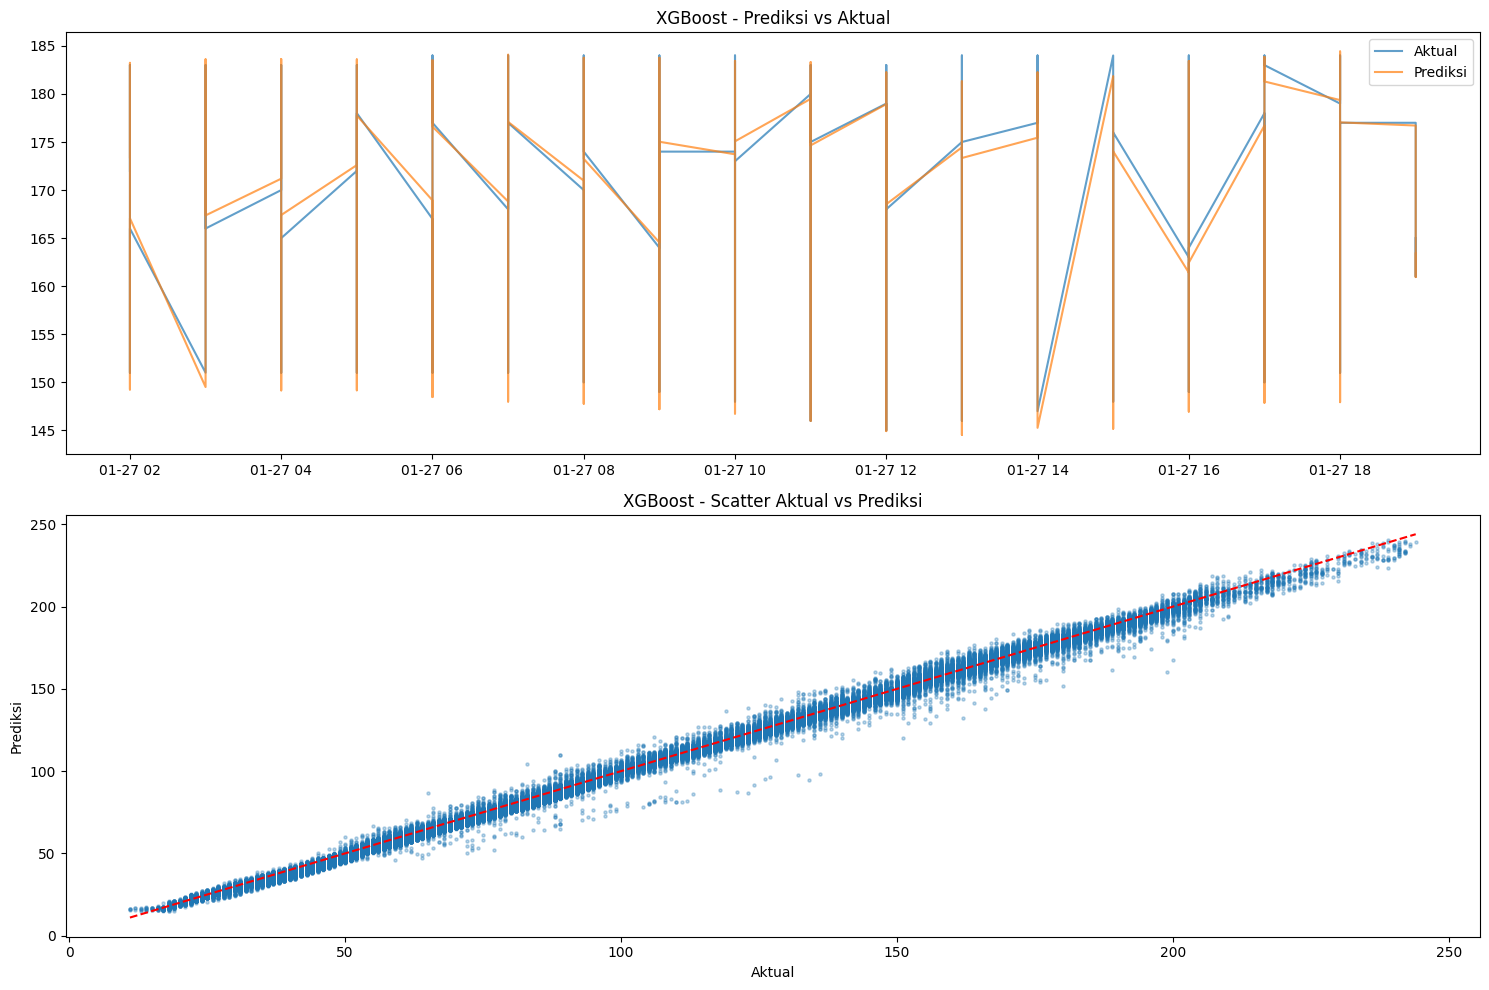

Plot disimpan ke results/plots/xgboost_prediction.png
Model disimpan ke models/xgboost_model.pkl


In [ ]:
import xgboost as xgb

# === Validation split: 10% terakhir dari train ===
val_size  = int(len(X_train_scaled) * 0.1)
X_tr  = X_train_scaled.iloc[:-val_size]
X_val = X_train_scaled.iloc[-val_size:]
y_tr  = y_train.iloc[:-val_size]
y_val = y_train.iloc[-val_size:]

print(f"Train: {X_tr.shape}, Val: {X_val.shape}, Test: {X_test_scaled.shape}")

# === Training XGBoost dengan early stopping ===
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20,
    eval_metric='rmse',
    random_state=42,
    n_jobs=-1,
    verbosity=1,
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

print(f"\nBest iteration : {xgb_model.best_iteration}")
print(f"Best val RMSE  : {xgb_model.best_score:.4f}")

# === Prediksi & Evaluasi ===
y_pred_xgb = xgb_model.predict(X_test_scaled)
metrics_list.append(evaluate(y_test, y_pred_xgb, 'XGBoost'))

plot_predictions(df_test['datetime'].values, y_test.values, y_pred_xgb, 'XGBoost')

# === Simpan model ===
os.makedirs('models', exist_ok=True)
joblib.dump(xgb_model, 'models/xgboost_model.pkl')
print("Model disimpan ke models/xgboost_model.pkl")

### 8.6 Export Model, Artifacts, dan Metrics

In [ ]:
all_metrics = pd.DataFrame(metrics_list)
all_metrics.to_csv('results/metrics_comparison.csv', index=False)

print('=== Perbandingan Metrik Semua Model ===')
print(all_metrics.to_string(index=False))

# Model XGBoost sudah disimpan di sel training
print('\nArtifak tersimpan:')
print('  results/metrics_comparison.csv')
print('  models/xgboost_model.pkl')

=== Perbandingan Metrik Semua Model ===
                      Model      MAE      RMSE       R2      MAPE
             Baseline Naive 1.251841  2.789903 0.996482  1.369496
Baseline Rolling Mean (24h) 8.593087 12.403936 0.930463 10.044196
                    XGBoost 1.305231  1.936075 0.998306  1.586073

Artifak tersimpan:
  results/metrics_comparison.csv
  models/xgboost_model.pkl


### 8.7 Visualisasi Perbandingan Metrik

C:\Users\faizn\AppData\Local\Temp\ipykernel_13204\3231693835.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_metrics, x='Model', y=metric, ax=ax, palette='viridis')
C:\Users\faizn\AppData\Local\Temp\ipykernel_13204\3231693835.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_metrics, x='Model', y=metric, ax=ax, palette='viridis')
C:\Users\faizn\AppData\Local\Temp\ipykernel_13204\3231693835.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_metrics, x='Model', y=metric, ax=ax, palette='viridis')
C:\Users\faiz

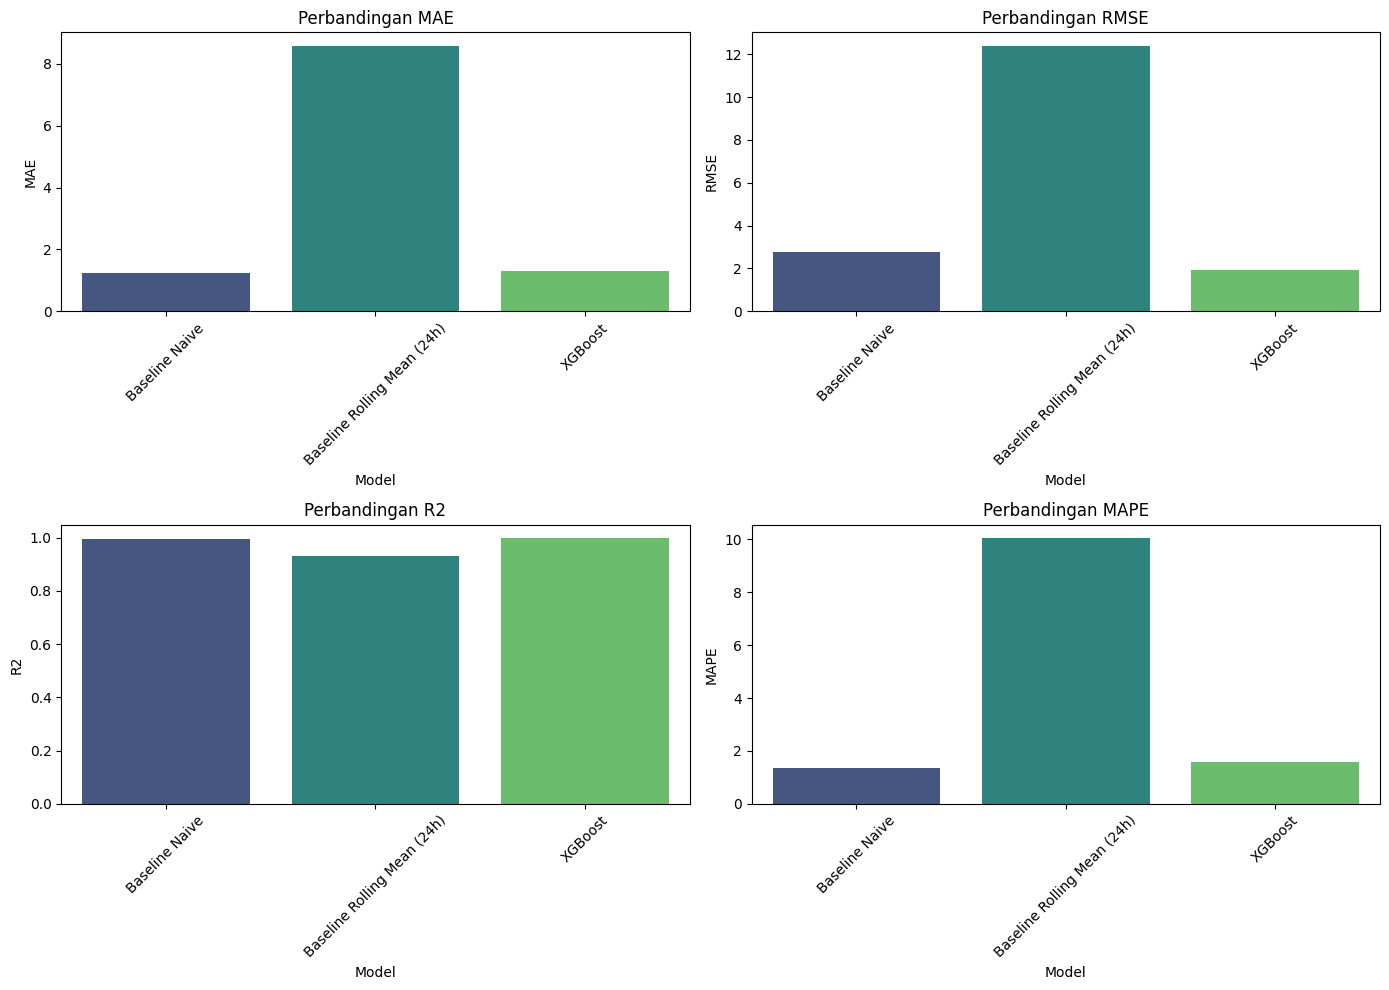

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_plot = ['MAE', 'RMSE', 'R2', 'MAPE']

for ax, metric in zip(axes.flat, metrics_plot):
    sns.barplot(data=all_metrics, x='Model', y=metric, ax=ax, palette='viridis')
    ax.set_title(f'Perbandingan {metric}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('results/plots/metrics_comparison_bar.png', dpi=120)
plt.show()

### 8.8 Interpretasi Kualitatif dan Kesimpulan

#### Mengapa XGBoost sebagai Model Utama?

Data AQI Bangladesh ini memiliki karakteristik yang sangat cocok untuk gradient boosting:

| Karakteristik Data | Implikasi untuk Model |
|---|---|
| 104 fitur tabular yang sudah direkayasa | XGBoost unggul pada tabular data vs neural network |
| Lag & rolling sudah eksplisit sebagai fitur | LSTM tidak punya "rahasia" tambahan dari raw sequence |
| Distribusi polutan right-skewed | Tree splits robust terhadap skewness, tidak perlu normalisasi khusus |
| 30+ kota dengan pola berbeda (`city_encoded`) | Tree bisa split per kota secara natural |
| Lag features berkorelasi tinggi | Multicollinearity tidak masalah untuk tree-based models |

#### Mengapa Baseline Naive Kompetitif di MAE?

Hasil evaluasi menunjukkan Baseline Naive (MAE = 1.25) sedikit lebih kecil dari XGBoost (MAE = 1.31) — ini bukan kelemahan model, melainkan konsekuensi dari **autokorelasi tinggi pada deret waktu AQI**:

- AQI per jam bersifat sangat persisten: nilai jam ini hampir selalu mendekati nilai jam sebelumnya (lag-1 autocorrelation ≈ 0.99)
- Akibatnya, prediksi paling sederhana pun (`y[t] = y[t-1]`) sudah memberikan MAE yang sangat kecil
- **XGBoost unggul signifikan di RMSE** (1.94 vs 2.79) dan **R²** (0.9983 vs 0.9965) — metrik yang lebih penting untuk aplikasi early warning karena menghukum kesalahan besar (spike AQI) lebih berat
- Untuk sistem peringatan dini polusi, **meminimalkan error ekstrem** (RMSE) lebih relevan daripada meminimalkan rata-rata error (MAE)

Evaluasi mendalam (residual analysis, per-city breakdown, walk-forward CV, extreme event analysis) tersedia di `06_model_evaluation.ipynb`.

#### Catatan Metodologi

- **Train-Test Split**: Time-aware (80% awal = train hingga Jan 2025, 20% akhir = test Jan–Nov 2025) — tidak ada data leakage temporal
- **Scaler**: RobustScaler di-fit hanya pada train set, lalu ditransformasi ke test
- **Early stopping**: Mencegah overfitting secara otomatis (monitoring val RMSE)

### 8.9 Validasi Anti-Leakage

In [ ]:
assert df_train['datetime'].max() < df_test['datetime'].min(), \
    'Data leakage! Train dan test overlap secara waktu!'
print('Validasi Anti-Leakage Passed:')
print(f'  Train max : {df_train["datetime"].max()}')
print(f'  Test  min : {df_test["datetime"].min()}')

Validasi Anti-Leakage Passed:
  Train max : 2025-01-27 01:00:00
  Test  min : 2025-01-27 02:00:00
